# Source selection

This notebook reproduces Figures 3–4, Tables 6–8, and the source-selection results in §4.2 from `raw/aio_results/` and the released PC1 lookup.

In [1]:
from pathlib import Path
import csv, json, math, re
from collections import Counter, defaultdict
from statistics import mean
from urllib.parse import parse_qsl, urlencode, urlparse

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from scipy.stats import chi2_contingency, f_oneway, t, ttest_ind, ttest_rel

ROOT = Path.cwd()
if not (ROOT / "raw").is_dir(): ROOT = ROOT.parent
RAW_AIOS = ROOT / "raw" / "aio_results"

CATEGORY_NAMES = {
    "autos_vehicles":"Autos & Vehicles", "beauty_fashion":"Beauty & Fashion",
    "business_finance":"Business & Finance", "climate":"Climate", "entertainment":"Entertainment",
    "food_drink":"Food & Drink", "games":"Games", "health":"Health",
    "hobbies_leisure":"Hobbies & Leisure", "jobs_education":"Jobs & Education",
    "law_gov":"Law & Government", "other":"Other", "pets_animals":"Pets & Animals",
    "politics":"Politics", "science":"Science", "shopping":"Shopping", "sports":"Sports",
    "technology":"Technology", "travel_transport":"Travel & Transport",
}
UGC_HOSTS = {"facebook.com","instagram.com","linkedin.com","pinterest.com","quora.com","reddit.com",
             "threads.com","threads.net","tiktok.com","twitter.com","x.com","youtube.com","m.youtube.com"}
TRACKING = {"gclid","fbclid","dclid","msclkid","mc_cid","mc_eid","igshid","ref","ref_src","sa","ved","srsltid","gclsrc"}

def category_from_path(path):
    folder = path.relative_to(RAW_AIOS).parts[1]
    return CATEGORY_NAMES[re.match(r"trending_US_1d_(.+?)_\d{4}-", folder).group(1)]

def host(url):
    value = (urlparse(url).hostname or "").lower()
    return value[4:] if value.startswith("www.") else value

def canonical_url(url):
    parsed = urlparse(url.strip())
    if parsed.scheme.lower() not in {"http","https"}: return None
    value = host(url)
    if not value: return None
    if value == "google.com" and parsed.path == "/url":
        target = dict(parse_qsl(parsed.query, keep_blank_values=True)).get("q") or dict(parse_qsl(parsed.query, keep_blank_values=True)).get("url")
        if not target: return None
        parsed = urlparse(target); value = host(target)
        if parsed.scheme.lower() not in {"http","https"} or not value: return None
    query = [(k,v) for k,v in parse_qsl(parsed.query, keep_blank_values=True)
             if not k.casefold().startswith("utm_") and k.casefold() not in TRACKING
             and not (value in {"youtube.com","m.youtube.com","youtu.be"} and k.casefold()=="t")]
    path = parsed.path or "/"
    if path != "/": path = path.rstrip("/") or "/"
    port = f":{parsed.port}" if parsed.port else ""
    return value + port + path + ("?" + urlencode(sorted(query)) if query else "")

def load_pc1(path):
    with path.open(encoding="utf-8") as handle:
        return {row["domain"].strip().lower():float(row["pc1"]) for row in csv.DictReader(handle) if row.get("pc1")}

def match_score(url, scores):
    parsed=urlparse(url); h=host(url)
    if not h: return None
    parts=[part for part in parsed.path.strip("/").split("/") if part]
    for size in range(len(parts),0,-1):
        key=h+"/"+"/".join(parts[:size])
        if key in scores: return scores[key]
    if h in scores: return scores[h]
    labels=h.split(".")
    while len(labels)>2:
        labels=labels[1:]; key=".".join(labels)
        if key in scores: return scores[key]
    return None

def show_table(frame, formats=None):
    output=frame.copy()
    for column,template in (formats or {}).items(): output[column]=output[column].map(template.format)
    display(HTML(output.to_html(index=False,border=0)))

def stars(p, tests=19):
    if p >= .05/tests: return ""
    return "***" if p < .001 else "**" if p < .01 else "*"

pc1 = load_pc1(ROOT / "replication" / "supporting" / "credibility" / "domain_pc1.csv")

## Build the comparison cohort

The source comparison excludes five AIO observations without saved SERP HTML and 16 with unresolved Google `/goto` links. AIO references retain repeated occurrences for UGC; PC1 removes fragment-only duplicates within each observation, matching the paper.

In [2]:
records=[]
all_ref_counts=[]; all_hosts=Counter()
for result_path in sorted(RAW_AIOS.rglob("result.json")):
    data=json.loads(result_path.read_text(encoding="utf-8"))
    category=category_from_path(result_path)
    refs=[r["url"] for r in ((data.get("aiOverview") or {}).get("references") or []) if isinstance(r,dict) and r.get("url")]
    all_ref_counts.append(len(refs)); all_hosts.update(host(url) for url in refs if host(url))
    serp=[url for url in (data.get("serpLinksDedup") or []) if isinstance(url,str)]
    has_goto=any(host(url)=="google.com" and urlparse(url).path.rstrip("/")=="/goto" for url in serp)
    if not (result_path.parent/"snapshot.html").is_file() or has_goto: continue

    aio_occurrence_scored=[(url,score) for url in refs if (score:=match_score(url,pc1)) is not None]
    aio_scored=[]; seen=set()
    for url in refs:
        key=url.split("#",1)[0]
        if key in seen: continue
        seen.add(key)
        score=match_score(url,pc1)
        if score is not None: aio_scored.append((url,score))
    serp_scored=[(position,url,score) for position,url in enumerate(serp,1) if (score:=match_score(url,pc1)) is not None]
    records.append(dict(category=category,refs=refs,serp=serp,aio_scored=aio_scored,aio_occurrence_scored=aio_occurrence_scored,serp_scored=serp_scored))

assert len(all_ref_counts)==7_583 and sum(all_ref_counts)==61_212 and len(all_hosts)==7_479
assert len(records)==7_562 and sum(len(r["refs"]) for r in records)==61_046 and sum(len(r["serp"]) for r in records)==241_710


## Figures 3–4 — Reference counts

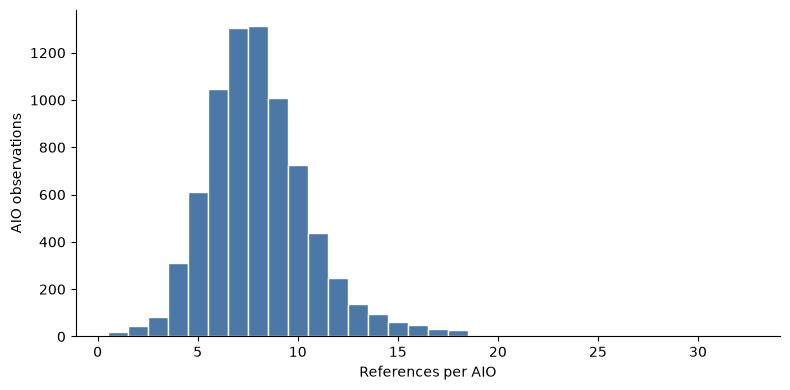

AIOs,Mean,Median,Minimum,Maximum
"7,583",8.1,8,1,32


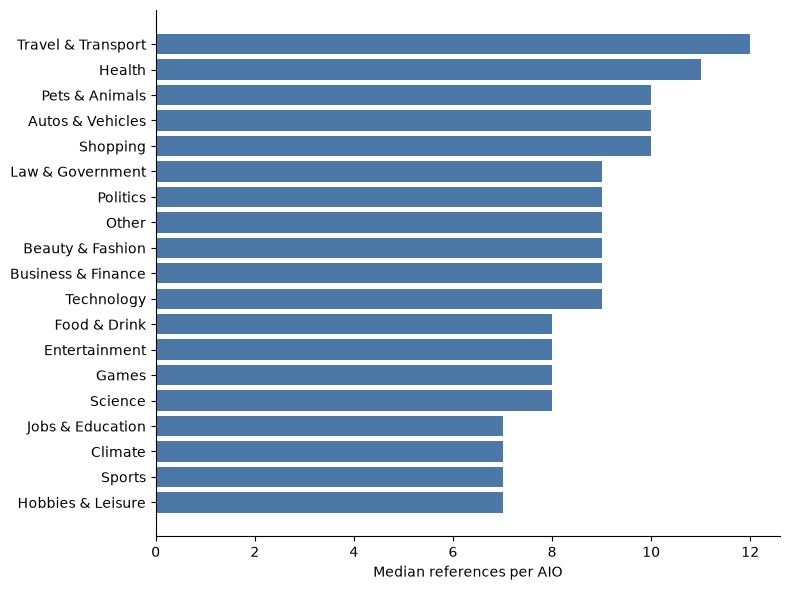

In [3]:
fig,ax=plt.subplots(figsize=(8,4))
bins=np.arange(.5,max(all_ref_counts)+1.5,1)
ax.hist(all_ref_counts,bins=bins,color="#4c78a8",edgecolor="white")
ax.set(xlabel="References per AIO",ylabel="AIO observations")
ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()

reference_summary=pd.DataFrame([[len(all_ref_counts),np.mean(all_ref_counts),np.median(all_ref_counts),min(all_ref_counts),max(all_ref_counts)]],
                               columns=["AIOs","Mean","Median","Minimum","Maximum"])
show_table(reference_summary,{"AIOs":"{:,}","Mean":"{:.1f}","Median":"{:.0f}"})

category_refs=defaultdict(list)
for result_path in RAW_AIOS.rglob("result.json"):
    d=json.loads(result_path.read_text(encoding="utf-8")); category_refs[category_from_path(result_path)].append(len((d.get("aiOverview") or {}).get("references") or []))
medians=pd.Series({k:np.median(v) for k,v in category_refs.items()}).sort_values()
fig,ax=plt.subplots(figsize=(8,6)); ax.barh(medians.index,medians.values,color="#4c78a8")
ax.set_xlabel("Median references per AIO"); ax.spines[["top","right"]].set_visible(False); fig.tight_layout(); plt.show()

## Reference reliance and overall PC1

In [4]:
concentration=pd.DataFrame([[k,100*sum(n for _,n in all_hosts.most_common(k))/sum(all_hosts.values())] for k in [5,10,50,100]],columns=["Top hostnames","Share of references"])
assert concentration["Share of references"].round(1).tolist()==[20.0,29.7,48.3,57.1]
show_table(concentration,{"Share of references":"{:.1f}%"})

top_hosts=pd.DataFrame(all_hosts.most_common(5),columns=["Hostname","References"]); top_hosts["Share"]=100*top_hosts["References"]/sum(all_hosts.values())
show_table(top_hosts,{"References":"{:,}","Share":"{:.2f}%"})

aio_scores=[score for r in records for _,score in r["aio_occurrence_scored"]]
serp_scores=[score for r in records for _,_,score in r["serp_scored"]]
aio_eligible=sum(len(r["refs"]) for r in records)
serp_eligible=sum(len(r["serp"]) for r in records)
welch=ttest_ind(aio_scores,serp_scores,equal_var=False)
se=math.sqrt(np.var(aio_scores,ddof=1)/len(aio_scores)+np.var(serp_scores,ddof=1)/len(serp_scores))
gap=np.mean(aio_scores)-np.mean(serp_scores)
assert (len(aio_scores),len(serp_scores))==(36_895,117_390)
assert (round(np.mean(aio_scores),3),round(np.mean(serp_scores),3),round(gap,3),round(welch.statistic,1))==(.732,.611,.122,107.1)
overall=pd.DataFrame([[
    len(aio_scores),100*len(aio_scores)/aio_eligible,np.mean(aio_scores),len(serp_scores),100*len(serp_scores)/serp_eligible,np.mean(serp_scores),gap,gap-1.96*se,gap+1.96*se,welch.statistic
]],columns=["AIO matched","AIO coverage","AIO mean","SERP matched","SERP coverage","SERP mean","Gap","CI low","CI high","Welch t"])
show_table(overall,{"AIO matched":"{:,}","SERP matched":"{:,}","AIO coverage":"{:.1f}%","SERP coverage":"{:.1f}%","AIO mean":"{:.3f}","SERP mean":"{:.3f}","Gap":"{:+.3f}","CI low":"{:.3f}","CI high":"{:.3f}","Welch t":"{:.1f}"})

Top hostnames,Share of references
5,20.0%
10,29.7%
50,48.3%
100,57.1%


Hostname,References,Share
youtube.com,"3,358",5.49%
en.wikipedia.org,"2,685",4.39%
facebook.com,"2,250",3.68%
instagram.com,"2,237",3.65%
usatoday.com,"1,716",2.80%


AIO matched,AIO coverage,AIO mean,SERP matched,SERP coverage,SERP mean,Gap,CI low,CI high,Welch t
"36,895",60.4%,0.732,"117,390",48.6%,0.611,+0.122,0.120,0.124,107.1


## Table 6 — PC1 by category

In [5]:
table6=[]
for category in CATEGORY_NAMES.values():
    a=[score for r in records if r["category"]==category for _,score in r["aio_occurrence_scored"]]
    s=[score for r in records if r["category"]==category for _,_,score in r["serp_scored"]]
    p=ttest_ind(a,s,equal_var=False).pvalue
    table6.append([category,np.mean(a),len(a),np.mean(s),len(s),np.mean(a)-np.mean(s),stars(p)])
table6=pd.DataFrame(table6,columns=["Category","AIO mean","AIO n","SERP mean","SERP n","Gap","Sig."]).sort_values("AIO mean",ascending=False)
table6.loc[len(table6)]=["All",np.mean(aio_scores),len(aio_scores),np.mean(serp_scores),len(serp_scores),gap,"***"]
assert table6.iloc[:-1]["AIO n"].sum()==36_895 and table6.iloc[:-1]["SERP n"].sum()==117_390
show_table(table6,{"AIO mean":"{:.3f}","AIO n":"{:,.0f}","SERP mean":"{:.3f}","SERP n":"{:,.0f}","Gap":"{:+.3f}"})

groups=[[score for r in records if r["category"]==category for _,score in r["aio_occurrence_scored"]] for category in CATEGORY_NAMES.values()]
anova=f_oneway(*groups)
display(Markdown(f"One-way ANOVA across AIO-reference PC1 by category: **F(18, {len(aio_scores)-19:,}) = {anova.statistic:.1f}, p < .001**."))

Category,AIO mean,AIO n,SERP mean,SERP n,Gap,Sig.
Science,0.769,"3,896",0.633,"12,175",+0.136,***
Business & Finance,0.751,"5,024",0.624,"15,317",+0.127,***
Sports,0.748,"11,943",0.611,"37,497",+0.137,***
Hobbies & Leisure,0.738,"2,911",0.631,"9,741",+0.107,***
Health,0.737,509,0.645,"1,426",+0.091,***
Politics,0.737,874,0.636,"2,838",+0.100,***
Food & Drink,0.734,353,0.602,966,+0.132,***
Climate,0.717,559,0.622,"1,919",+0.095,***
Law & Government,0.714,"1,354",0.617,"4,142",+0.097,***
Other,0.699,"1,961",0.596,"6,270",+0.104,***


One-way ANOVA across AIO-reference PC1 by category: **F(18, 36,876) = 58.0, p < .001**.

## Table 7 — Query-paired PC1

In [6]:
def paired_row(label,selector):
    pairs=[]
    for r in records:
        if not r["aio_occurrence_scored"]: continue
        selected=selector(r["serp_scored"])
        if selected: pairs.append((mean(score for _,score in r["aio_occurrence_scored"]),selected))
    a=np.array([x for x,_ in pairs]); s=np.array([y for _,y in pairs]); d=a-s
    test=ttest_rel(a,s); se=d.std(ddof=1)/math.sqrt(len(d)); margin=t.ppf(.975,len(d)-1)*se
    return [label,len(d),a.mean(),s.mean(),d.mean(),d.mean()/d.std(ddof=1),d.mean()-margin,d.mean()+margin,test.pvalue]

rows=[]
for k in [1,3,5,10]:
    rows.append(paired_row(f"Top {k}",lambda values,k=k: mean([score for pos,_,score in values if pos<=k]) if any(pos<=k for pos,_,score in values) else None))
rows.append(paired_row("Full",lambda values: mean(score for _,_,score in values) if values else None))
for rho in [.5,.8]:
    rows.append(paired_row(f"Geometric {rho}",lambda values,rho=rho: sum((1-rho)*rho**(pos-1)*score for pos,_,score in values)/sum((1-rho)*rho**(pos-1) for pos,_,score in values) if values else None))
table7=pd.DataFrame(rows,columns=["SERP specification","n","AIO mean","SERP mean","Gap","dz","CI low","CI high","p"])
assert table7["n"].tolist()==[5_020,6_534,6_942,7_342,7_444,7_444,7_444]
assert table7["Gap"].round(3).tolist()==[-.037,-.017,-.006,.034,.110,-.016,.021]
show_table(table7,{"n":"{:,}","AIO mean":"{:.3f}","SERP mean":"{:.3f}","Gap":"{:+.3f}","dz":"{:+.3f}","CI low":"{:+.3f}","CI high":"{:+.3f}","p":"{:.3g}"})

SERP specification,n,AIO mean,SERP mean,Gap,dz,CI low,CI high,p
Top 1,"5,020",0.740,0.777,-0.037,-0.235,-0.042,-0.033,7.99e-61
Top 3,"6,534",0.736,0.753,-0.017,-0.117,-0.020,-0.013,5.64e-21
Top 5,"6,942",0.734,0.740,-0.006,-0.045,-0.009,-0.003,0.000205
Top 10,"7,342",0.730,0.696,+0.034,+0.264,+0.031,+0.037,8.6e-110
Full,"7,444",0.728,0.618,+0.110,+0.978,+0.108,+0.113,0
Geometric 0.5,"7,444",0.728,0.744,-0.016,-0.111,-0.019,-0.013,1.21e-21
Geometric 0.8,"7,444",0.728,0.707,+0.021,+0.179,+0.019,+0.024,3.72e-53


## Table 8 — UGC in AIO references and SERP links

In [7]:
ugc_rows=[]
for category in CATEGORY_NAMES.values():
    subset=[r for r in records if r["category"]==category]
    aio=[url for r in subset for url in r["refs"]]; serp=[url for r in subset for url in r["serp"]]
    au=sum(host(url) in UGC_HOSTS for url in aio); su=sum(host(url) in UGC_HOSTS for url in serp)
    p=chi2_contingency([[au,len(aio)-au],[su,len(serp)-su]],correction=False).pvalue
    ap=100*au/len(aio); sp=100*su/len(serp)
    ugc_rows.append([category,ap,len(aio),sp,len(serp),ap-sp,stars(p)])
table8=pd.DataFrame(ugc_rows,columns=["Category","AIO UGC","AIO n","SERP UGC","SERP n","Gap","Sig."]).sort_values("AIO UGC",ascending=False)
aio_n=table8["AIO n"].sum(); serp_n=table8["SERP n"].sum()
aio_u=sum(sum(host(url) in UGC_HOSTS for url in r["refs"]) for r in records); serp_u=sum(sum(host(url) in UGC_HOSTS for url in r["serp"]) for r in records)
table8.loc[len(table8)]=["All",100*aio_u/aio_n,aio_n,100*serp_u/serp_n,serp_n,100*aio_u/aio_n-100*serp_u/serp_n,"***"]
assert (aio_u,aio_n,serp_u,serp_n)==(8_671,61_046,120_695,241_710)
show_table(table8,{"AIO UGC":"{:.2f}%","AIO n":"{:,.0f}","SERP UGC":"{:.2f}%","SERP n":"{:,.0f}","Gap":"{:+.2f} pp"})

Category,AIO UGC,AIO n,SERP UGC,SERP n,Gap,Sig.
Beauty & Fashion,28.85%,52,60.99%,223,-32.14 pp,***
Autos & Vehicles,27.42%,186,46.87%,958,-19.45 pp,***
Shopping,25.86%,232,54.41%,952,-28.55 pp,***
Pets & Animals,20.90%,67,47.19%,320,-26.29 pp,***
Technology,20.29%,828,53.37%,"3,013",-33.08 pp,***
Travel & Transport,20.00%,290,45.59%,"1,303",-25.59 pp,***
Entertainment,19.41%,"10,461",56.63%,"44,022",-37.22 pp,***
Food & Drink,18.72%,561,52.34%,"2,117",-33.62 pp,***
Games,18.13%,662,53.82%,"2,863",-35.70 pp,***
Other,16.21%,"3,725",44.93%,"14,018",-28.71 pp,***


## AIO/SERP overlap and off-page references

In [8]:
overlap={5:[],10:[],"Full":[]}; on_pc1=[]; off_pc1=[]; on_ugc=off_ugc=on_n=off_n=0
for r in records:
    aio_domains={host(url) for url in r["refs"] if host(url)}
    ordered=[host(url) for url in r["serp"]]
    if aio_domains:
        for key,k in [(5,5),(10,10),("Full",len(ordered))]:
            overlap[key].append(len(aio_domains & {value for value in ordered[:k] if value})/len(aio_domains))
    full={value for value in ordered if value}
    for url in r["refs"]:
        domain=host(url)
        if not domain: continue
        is_on=domain in full; score=match_score(url,pc1)
        if is_on:
            on_n+=1; on_ugc+=domain in UGC_HOSTS
            if score is not None: on_pc1.append(score)
        else:
            off_n+=1; off_ugc+=domain in UGC_HOSTS
            if score is not None: off_pc1.append(score)

overlap_table=pd.DataFrame([[str(k),100*np.mean(v)] for k,v in overlap.items()],columns=["SERP scope","Mean AIO domain overlap"])
assert overlap_table["Mean AIO domain overlap"].round(1).tolist()==[31.5,48.0,70.2]
show_table(overlap_table,{"Mean AIO domain overlap":"{:.1f}%"})

off_test=ttest_ind(off_pc1,on_pc1,equal_var=False)
offpage=pd.DataFrame([
    ["Off-page",len(off_pc1),np.mean(off_pc1),off_ugc,off_n,100*off_ugc/off_n],
    ["On-page",len(on_pc1),np.mean(on_pc1),on_ugc,on_n,100*on_ugc/on_n],
],columns=["Reference group","PC1 n","Mean PC1","UGC n","All n","UGC share"])
assert (len(off_pc1),len(on_pc1),off_ugc,off_n,on_ugc,on_n)==(9_218,27_677,590,17_399,8_081,43_641)
show_table(offpage,{"PC1 n":"{:,}","Mean PC1":"{:.3f}","UGC n":"{:,}","All n":"{:,}","UGC share":"{:.2f}%"})
display(Markdown(f"Off-page minus on-page PC1: **{np.mean(off_pc1)-np.mean(on_pc1):+.3f}**, Welch p **< .001**. Off-page share: **{100*(1-np.mean(overlap['Full'])):.1f}%**."))

SERP scope,Mean AIO domain overlap
5,31.5%
10,48.0%
Full,70.2%


Reference group,PC1 n,Mean PC1,UGC n,All n,UGC share
Off-page,"9,218",0.757,590,"17,399",3.39%
On-page,"27,677",0.724,"8,081","43,641",18.52%


Off-page minus on-page PC1: **+0.033**, Welch p **< .001**. Off-page share: **29.8%**.